Import Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import date
import calendar


Read the data

In [49]:
df = pd.read_csv("data.csv", encoding="latin-1")
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Identify nulls with Heatmap

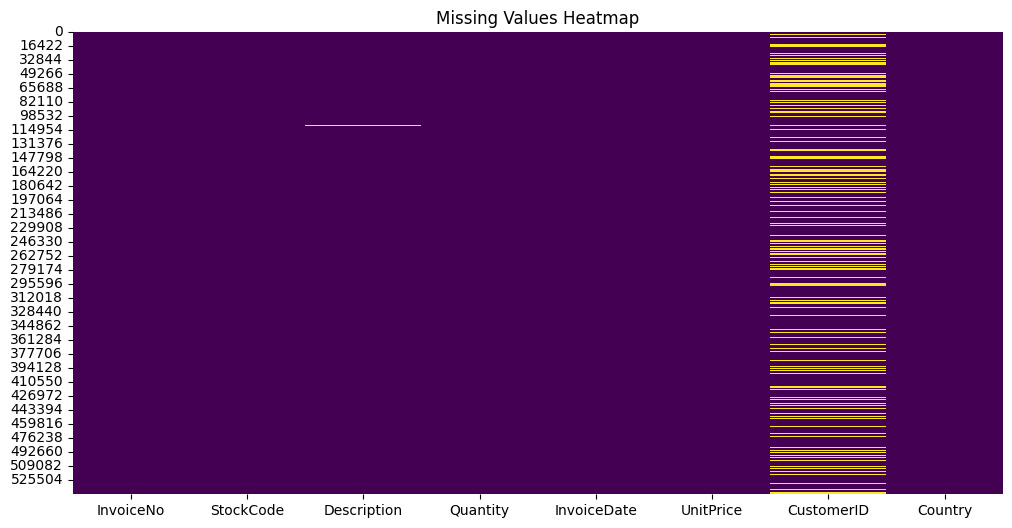

In [50]:

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

Dataset information

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [52]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Drop nulls from the dataset

In [53]:
df = df.dropna()
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [55]:
df.shape

(406829, 8)

Data Transformations

In [56]:
df["CustomerID"] = df["CustomerID"].astype("int")
df["CustomerID"] = df["CustomerID"].astype("object")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
#df["InvoiceDate"] = df["InvoiceDate"].dt.date
df["Total_Amount"] = df["Quantity"] * df["UnitPrice"]
df["Order_Type"] = np.where(df["InvoiceNo"].str.startswith("C"), "Return", "Normal")


Check datatypes and info

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     406829 non-null  object        
 1   StockCode     406829 non-null  object        
 2   Description   406829 non-null  object        
 3   Quantity      406829 non-null  int64         
 4   InvoiceDate   406829 non-null  datetime64[ns]
 5   UnitPrice     406829 non-null  float64       
 6   CustomerID    406829 non-null  object        
 7   Country       406829 non-null  object        
 8   Total_Amount  406829 non-null  float64       
 9   Order_Type    406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 34.1+ MB


## Top 5 Highest selling products

In [58]:

HighSalesProduct = df[(df["Order_Type"] == "Normal")].groupby(["StockCode", "Description"])["Total_Amount"].sum().reset_index()
HighSalesProduct.columns = ["StockCode", "Desc", "Amount"]
HighSalesProduct = HighSalesProduct.sort_values(by = "Amount", ascending= False).head(5)
HighSalesProduct = HighSalesProduct.reset_index(drop=True)
display(HighSalesProduct)


,StockCode,Desc,Amount
0,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,22423,REGENCY CAKESTAND 3 TIER,142592.95
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100448.15
3,85099B,JUMBO BAG RED RETROSPOT,85220.78
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73


## Normal vs Return Orders

In [59]:
ordertypesales = df.groupby("Order_Type")["Total_Amount"].sum().reset_index(name = "Sales_Amount")
#ordertypesales["Sales_Amount"] = abs(ordertypesales["Sales_Amount"])
ordertypesales["Percent"] = abs(ordertypesales["Sales_Amount"] / abs(ordertypesales["Sales_Amount"]).sum()) * 100 
display(ordertypesales[["Order_Type", "Percent"]])


,Order_Type,Percent
0,Normal,93.580194
1,Return,6.419806


## Top 5 Country in terms of sales and Percentage

,Country,Total_Sales
0,United Kingdom,7308391.554
1,Netherlands,285446.340
2,EIRE,265545.900
3,Germany,228867.140
4,France,209024.050


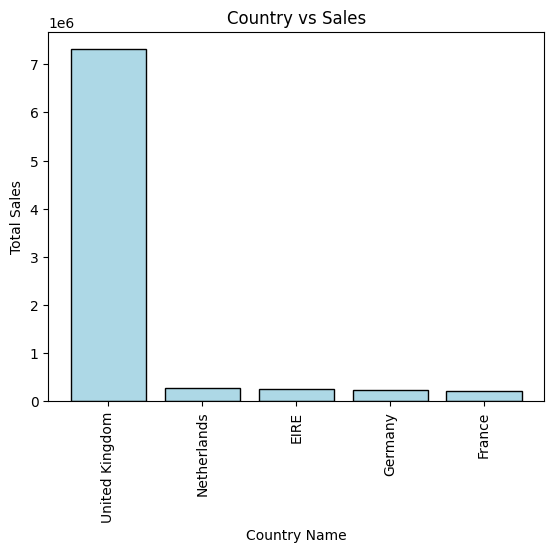

In [60]:
TopFiveCountries = df[(df["Order_Type"] == "Normal")].groupby("Country")["Total_Amount"].sum().nlargest(5).reset_index()
TopFiveCountries.columns = ["Country", "Total_Sales"]
display(TopFiveCountries)


plt.bar(TopFiveCountries["Country"], TopFiveCountries["Total_Sales"], color = "lightblue", edgecolor = "black")
plt.xticks(rotation = 90)
plt.xlabel("Country Name")
plt.ylabel("Total Sales")
plt.title("Country vs Sales")
plt.show()

In [61]:

TopFiveCountriesPercent = df[df["Order_Type"] == "Normal"].groupby("Country")["Total_Amount"].sum().reset_index(name = "Sales_Amount")
TopFiveCountriesPercent["Percent"] = abs(TopFiveCountriesPercent["Sales_Amount"] / abs(TopFiveCountriesPercent["Sales_Amount"]).sum()) * 100 
TopFiveCountriesPercent = TopFiveCountriesPercent[["Country", "Percent"]]
TopFiveCountriesPercent = TopFiveCountriesPercent.sort_values(by="Percent", ascending=False).head(5)
display(TopFiveCountriesPercent)


,Country,Percent
35,United Kingdom,82.011638
23,Netherlands,3.203156
10,EIRE,2.979842
14,Germany,2.568249
13,France,2.345578


## Countries with unique customers

In [62]:

uniquecustomerspercountry = df.groupby("Country")["CustomerID"].nunique().reset_index(name="Cust")
uniquecustomerspercountry = uniquecustomerspercountry.sort_values(by="Cust", ascending = False)
print(uniquecustomerspercountry)


                 Country  Cust
35        United Kingdom  3950
14               Germany    95
13                France    87
30                 Spain    31
3                Belgium    25
32           Switzerland    21
26              Portugal    19
18                 Italy    15
12               Finland    12
1                Austria    11
24                Norway    10
23           Netherlands     9
0              Australia     9
9                Denmark     9
6        Channel Islands     9
7                 Cyprus     8
31                Sweden     8
19                 Japan     8
25                Poland     6
33                   USA     4
5                 Canada     4
36           Unspecified     4
17                Israel     4
15                Greece     4
10                  EIRE     3
22                 Malta     2
34  United Arab Emirates     2
2                Bahrain     2
8         Czech Republic     1
21             Lithuania     1
20               Lebanon     1
27      

In [63]:
df["CustomerID"] = df["CustomerID"].astype(str)
df["CustomerID"] = df["CustomerID"].str.strip()

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     406829 non-null  object        
 1   StockCode     406829 non-null  object        
 2   Description   406829 non-null  object        
 3   Quantity      406829 non-null  int64         
 4   InvoiceDate   406829 non-null  datetime64[ns]
 5   UnitPrice     406829 non-null  float64       
 6   CustomerID    406829 non-null  object        
 7   Country       406829 non-null  object        
 8   Total_Amount  406829 non-null  float64       
 9   Order_Type    406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 34.1+ MB


## Sales trends

,InvoiceDate,Total_Amount,Month_Year
0,2010-12-31,554604.020,Dec-2010
1,2011-01-31,475074.380,Jan-2011
2,2011-02-28,436546.150,Feb-2011
3,2011-03-31,579964.610,Mar-2011
4,2011-04-30,426047.851,Apr-2011
5,2011-05-31,648251.080,May-2011
6,2011-06-30,608013.160,Jun-2011
7,2011-07-31,574238.481,Jul-2011
8,2011-08-31,616368.000,Aug-2011
9,2011-09-30,931440.372,Sep-2011


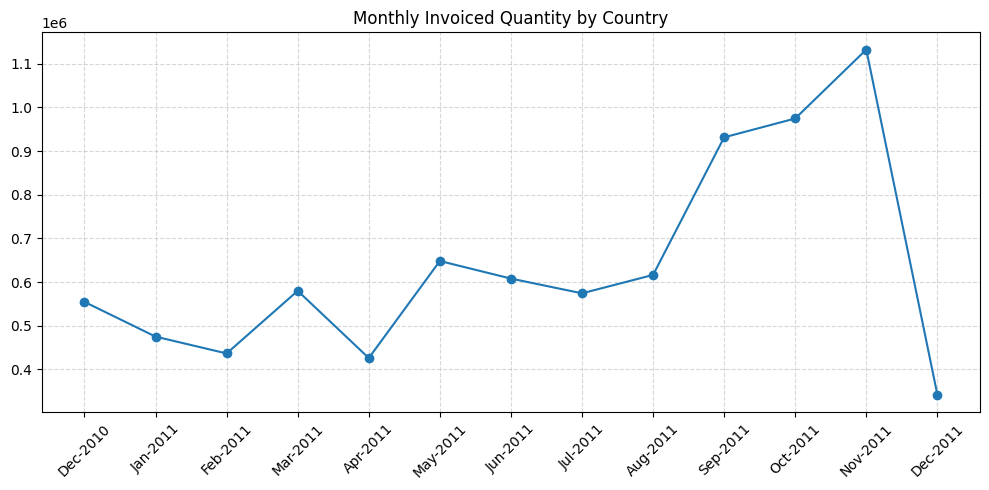

In [65]:
de = df.copy()
de["InvoiceDate"] = pd.to_datetime(de["InvoiceDate"])

de = de.set_index("InvoiceDate").resample("ME")["Total_Amount"].sum().reset_index()
de["Month_Year"] = de["InvoiceDate"].dt.strftime("%b-%Y")
display(de)


plt.figure(figsize=(10,5))
plt.plot(de["Month_Year"], de["Total_Amount"], marker = "o")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.title("Monthly Invoiced Quantity by Country")
plt.tight_layout()
plt.show()


# RFM
### Using this method we can segregate the customers based on different segments and get insights on customer analytics

,CustomerID,Revenue,InvoiceMaxDate,InvoiceRaised,InvoiceReturn,RecencyInDays,TotalInvoiceRaised,Revenue_pct,RecencyInDays_pct,Invoice_pct,re_bin,freq_bin,mon_bin,RFM,Segment
0,12346,0.000000,2011-01-18 10:17:00,2,1,325,1,0.989494,0.962532,0.178481,3,1,3,313,New Customer
1,12747,40.737961,2011-12-07 14:34:00,11,0,2,11,0.113165,0.045696,0.927975,1,3,1,131,At Risk
2,12748,6.262839,2011-12-09 12:20:00,224,14,0,210,0.866582,0.004051,1.000000,1,3,3,133,At Risk
3,12749,16.745455,2011-12-06 09:56:00,8,3,3,5,0.486076,0.068987,0.772405,1,3,2,132,At Risk
4,12820,15.971864,2011-12-06 15:12:00,4,0,3,4,0.538228,0.068987,0.700506,1,3,2,132,At Risk
5,12821,15.453333,2011-05-09 15:51:00,1,0,214,1,0.572152,0.846329,0.178481,3,1,2,312,New Customer
6,12822,19.552766,2011-09-30 10:04:00,3,1,70,2,0.340000,0.598608,0.443924,2,2,2,222,Loyal Customers
7,12823,351.900000,2011-09-26 07:35:00,5,0,74,5,0.008354,0.620759,0.772405,2,3,1,231,Potential
8,12824,15.884800,2011-10-11 12:49:00,1,0,59,1,0.543797,0.551392,0.178481,2,1,2,212,Potential
9,12826,15.618298,2011-12-07 10:25:00,8,1,2,7,0.560506,0.045696,0.856329,1,3,2,132,At Risk


,Segment,Customer_Count
0,At Risk,1154
1,Champions,44
2,Lost,149
3,Loyal Customers,897
4,New Customer,797
5,Potential,909


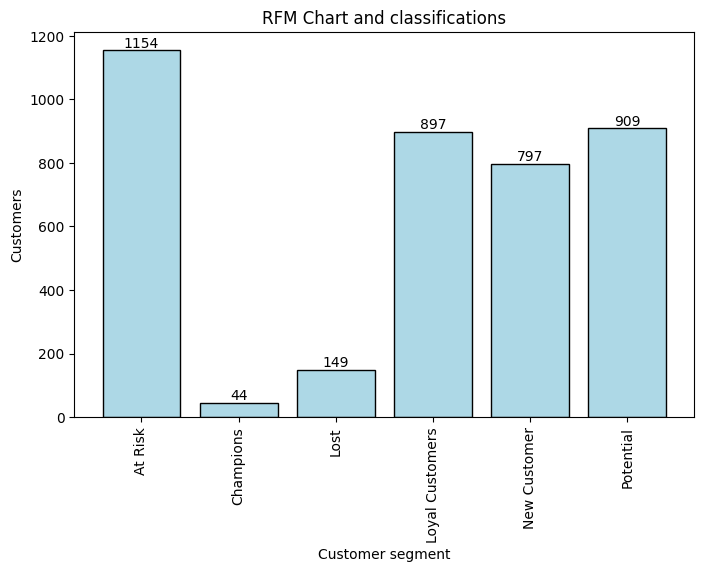

In [96]:
ca = df[df["Country"] == "United Kingdom"]

ca = ca.groupby("CustomerID").agg(Revenue = ("Total_Amount", "mean"), InvoiceMaxDate = ("InvoiceDate", "max"), InvoiceRaised = ("InvoiceNo", "nunique"), InvoiceReturn = ("InvoiceNo", lambda x: x[x.str.startswith("C")].nunique()))
ca["RecencyInDays"] =  (pd.Timestamp("2011-12-10") - ca["InvoiceMaxDate"]).dt.days
ca["TotalInvoiceRaised"] = ca["InvoiceRaised"] - ca["InvoiceReturn"]
ca = ca.reset_index()

ca["Revenue_pct"] = ca["Revenue"].rank(pct=True, ascending = False)
ca["RecencyInDays_pct"] = ca["RecencyInDays"].rank(pct=True)
ca["Invoice_pct"] = ca["TotalInvoiceRaised"].rank(pct=True)

partition = [0,0.33,0.66,1]
lab = [1,2,3]

ca["re_bin"] = pd.cut(ca["RecencyInDays_pct"], bins =partition, labels=lab).astype("str")
ca["freq_bin"] = pd.cut(ca["Invoice_pct"], bins=partition, labels=lab).astype("str")
ca["mon_bin"] = pd.cut(ca["Revenue_pct"], bins=partition, labels=lab).astype("str")

ca["RFM"] = ca["re_bin"] + ca["freq_bin"] + ca["mon_bin"]

# This can be changed based on business requirement
def segment_customer(rfm):
    r = int(rfm[0])  
    f = int(rfm[1])  
    m = int(rfm[2])  
    
    if r == 3 and f == 3 and m == 3:
        return "Champions"
    elif r >= 2 and f >= 2 and m >= 2:
        return "Loyal Customers"
    elif r == 3 and f == 1:
        return "New Customer"
    elif r == 1 and f >= 2:
        return "At Risk"
    elif r == 1 and f == 1:
        return "Lost"
    else:
        return "Potential"

ca["Segment"] = ca["RFM"].apply(segment_customer)

display(ca.head(10))
segmentation = ca.groupby("Segment").agg(Customer_Count = ("CustomerID", "count")).reset_index()
display(segmentation)


plt.figure(figsize=(8,5))
b = plt.bar(segmentation["Segment"], segmentation["Customer_Count"], color = "lightblue", edgecolor = "black")
plt.xticks(rotation = 90)
plt.xlabel("Customer segment")
plt.ylabel("Customers")
plt.title("RFM Chart and classifications")
plt.bar_label(b)
plt.show()

